# **Assemble Data**

In [1]:
# Importation des library
from datasets import load_dataset
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv

/home/superrama/sma-llms/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Chargement du dataset IMDb depuis la bibliothèque Hugging Face Datasets
ds = load_dataset("imdb")

In [3]:
# Affichage dataset
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [4]:
# Conversion de la partition d'entraînement en DataFrame pandas pour faciliter le prétraitement
train_df = ds['train'].to_pandas()

In [5]:
# Inspection visuelle de 10 échantillons aléatoires pour vérifier la structure des données
train_df.sample(10)

,text,label
5693,I almost drowned in CHEESE watching this movie...,0
7678,A phenomenal achievement in awfulness. It's ac...,0
11271,From around the time Europe began fighting Wor...,0
7049,This is some of the worst acting I have ever s...,0
24429,"The most amazing, spiritually uplifting movie ...",1
2774,Actress Ruth Roman's real-life philanthropic g...,0
12498,Any film which begins with a cowhand shagging ...,0
13447,Wow! So much fun! Probably a bit much for norm...,1
7722,"Strange, almost all reviewers are highly posit...",0
20199,I love Ashley Judd and think all of her movies...,1


In [6]:
# Vérification de l'équilibre des classes (0=négatif, 1=positif)
train_df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

In [7]:
# Création d'une colonne 'sentiment' en texte lisible pour interprétation humaine
# Transformation : 1 → "positive", 0 → "negative"
train_df['sentiment']=np.where(train_df.label==1,"positive", "negative")

In [8]:
# Visualisation globale du DataFrame pour vérifier l'ensemble des colonnes et un aperçu des données
train_df

,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negative
2,If only to avoid making this type of film in t...,0,negative
3,This film was probably inspired by Godard's Ma...,0,negative
4,"Oh, brother...after hearing about this ridicul...",0,negative
...,...,...,...
24995,A hit at the time but now better categorised a...,1,positive
24996,I love this movie like no other. Another time ...,1,positive
24997,This film and it's sequel Barry Mckenzie holds...,1,positive
24998,'The Adventures Of Barry McKenzie' started lif...,1,positive


In [9]:
# Vérification de la distribution des sentiments après ajout de la colonne textuelle
# Confirmation que le mapping 0→negative, 1→positive a bien fonctionné
train_df.sentiment.value_counts()

sentiment
negative    12500
positive    12500
Name: count, dtype: int64

<Axes: >

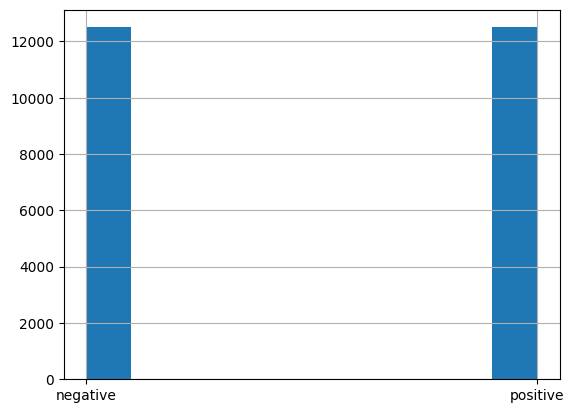

In [10]:
# Visualisation de la distribution des classes sous forme d'histogramme
train_df.sentiment.hist()

In [11]:
# Séparation du dataset d'entraînement en deux parties 
examples_df, gold_examples_df = train_test_split(
    train_df, test_size=0.2, random_state=123
)

In [ ]:
# Vérification des dimensions après split 80/20
examples_df.shape, gold_examples_df.shape

((20000, 3), (5000, 3))

In [13]:
# Création d'un échantillon de référence (gold examples) pour évaluation des prompts
# Sélection aléatoire de 20 critiques avec leurs sentiments associés
# Format JSON pour intégration facile dans les tests de prompts
columns = ['text', 'sentiment']
gold_examples = (gold_examples_df[columns]
                 .sample(20, random_state=34)
                 .to_json(orient='records')
                 )

In [14]:
# Importation de la bibliothèque
import json

In [15]:
# Inspection du premier exemple du golden dataset pour vérifier le format
# Retourne un dictionnaire avec les clés 'text' et 'sentiment'
json.loads(gold_examples)[0]

{'text': '"A Guy Thing" may not be a classic, but it sure is a good, funny comedy. The plot focuses on Paul (Jason Lee), who wakes up the morning after his bachelor party with no memory and Becky (Julia Stiles) lying naked in his bed. Before he can figure out what happened, he rushes Becky out of his apartment because his fiance Karen (Selma Blair) is coming. After that, as you could imagine, chaos ensues.<br /><br />Almost every single scene in "A Guy Thing" delivers loud laughs. The funniest moments come from when Paul imagines what could happen if he tells Karen. Selma Blair is a truly talented comedian, and the worst thing about this film is that she goes underused. Although, she turns out to be more funny than Stiles\' character, who actually isn\'t that interesting. Of course, not every comedy is perfect.<br /><br />As I said, "A Guy Thing" is no classic, but it\'s not bad either, 7/10.',
 'sentiment': 'positive'}

In [16]:
# Template pour formater les critiques de film dans le message utilisateur
user_message_template = """```{movie_review}```"""

In [17]:
# Préparation du prompt au format OpenAI/Claude compatible
# Structure : liste de messages avec rôles
# Ici uniquement le rôle 'system' car zero-shot pur
# Les messages 'user' seront ajoutés dynamiquement pendant l'évaluation
zero_shot_system_message = """
Classify the sentiment of movie reviews presented in the input as
'positive' or 'negative'Movie reviews will be delimited by triple backticks in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.
"""
zero_shot_prompt = [{'role':'system', 'content':
zero_shot_system_message}]

In [18]:
# Instructions identiques au zero-shot pour la tâche de classification
few_shot_system_message = """
Classify the sentiment of movie reviews presented in the input as
'positive' or 'negative'
Movie reviews will be delimited by triple backticks in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.
"""

In [19]:
# Création d'un masque booléen pour filtrer les critiques positives
positive_reviews = (examples_df.sentiment == 'positive')
# Création d'un masque booléen pour filtrer les critiques négatives
negative_reviews = (examples_df.sentiment == 'negative')

In [20]:
# Vérification des dimensions des masques booléens
(positive_reviews.shape, negative_reviews.shape)

((20000,), (20000,))

In [21]:
# Sélection des colonnes utiles pour les exemples (texte + sentiment)
columns = ['text', 'sentiment']
# Extraction aléatoire de 4 critiques positives représentatives
positive_examples = examples_df.loc[positive_reviews,
columns].sample(4)
# Extraction aléatoire de 4 critiques négatives pour équilibrer le prompt
# Total de 8 exemples (4 positifs + 4 négatifs) dans le contexte few-shot
negative_examples = examples_df.loc[negative_reviews,
columns].sample(4)

In [22]:
# Affichage des reponses positives
positive_examples

,text,sentiment
15704,I got this film about a month ago and I am now...,positive
14910,"Reese Witherspoon plays Dani, a young country ...",positive
19577,"Well, when before I saw this film I really was...",positive
24610,Nina Foch delivers a surprisingly strong perfo...,positive


In [26]:
# Affichage des reponses negatives
negative_examples

,text,sentiment
4677,This film is about a Japanese woman who has an...,negative
1094,There is not a single sympathetic character in...,negative
4289,This is pretty much the first Jason Scott Lee ...,negative
7658,This movie is a vehicle for Schwarzenegger-clo...,negative


In [32]:
def create_examples(dataset, n=4):
        # Création des masques booléens pour filtrer par sentiment
    positive_reviews = (dataset.sentiment == 'positive')
    negative_reviews = (dataset.sentiment == 'negative')
        # Restriction aux colonnes utiles pour le prompt
    columns_to_select = ['text', 'sentiment']
        # Échantillonnage aléatoire de n critiques positives
    positive_examples = dataset.loc[positive_reviews,
columns_to_select].sample(n)
        # Échantillonnage symétrique de n critiques négatives
    negative_examples = dataset.loc[negative_reviews,
columns_to_select].sample(n)
        # Concatenation des deux sous-ensembles pour obtenir 2n exemples
    examples = pd.concat([positive_examples, negative_examples])
    # sampling without replacement is equivalent to random shuffling
    randomized_examples = examples.sample(2*n, replace=False)
    return randomized_examples.to_json(orient='records')

# Appel de la fonction pour générer 4 exemples (2 positifs, 2 négatifs)
examples = create_examples(examples_df, 2)
# Inspection du résultat pour validation du format et du contenu
json.loads(examples)

[{'text': "In a future society, the military component does not have to recruit; rather, their candidates are chosen at birth, culled from nurseries and designated to spend their entire lives in the service of the government. They are given over to the war machine, body and soul, for no reason other than to protect and serve; they have no personal identity other than a name and rank, and no autonomy whatsoever. This is the fate of those whose destiny is predetermined for them in `Soldier,' directed by Paul Anderson and starring Kurt Russell. The scenario is hard and bleak as the movie begins by depicting the training of the soldiers during advancing periods of time, from preadolescence to adulthood. Russell is Sergeant Todd, the best of the best, and we glimpse his career as he discharges his duties in an exemplary manner in campaign after campaign; he is what he was born to be, a soldier. But even the best cannot go on forever, and the day arrives when Todd and his peers are no longer

In [31]:
def create_prompt(system_message, examples, user_message_template):
    # Initialisation du prompt avec le message système (rôle 'system')
    # Ce message définit le comportement général attendu du modèle
    few_shot_prompt = [{'role':'system', 'content': system_message}]
    # Parsing du JSON pour itérer sur chaque exemple
    # Chaque exemple est un dict avec 'text' et 'sentiment'
    for example in json.loads(examples):
        example_review = example['text'] # Critique de film
        example_sentiment = example['sentiment'] # Sentiment associé (positive/negative)

        # Ajout du message utilisateur avec la critique formatée
        few_shot_prompt.append(
        {
            'role': 'user',
            'content': user_message_template.format(
                movie_review=example_review
            )
        }
    )
    # Ajout de la réponse attendue de l'assistant
    few_shot_prompt.append(
        {'role': 'assistant', 'content': f"{example_sentiment}"}
    )
    # Retourne la structure complète du prompt
    return few_shot_prompt

# === CONSTRUCTION DU PROMPT FEW-SHOT ===
# Utilisation de la fonction avec nos paramètres configurés
few_shot_prompt = create_prompt(
    few_shot_system_message, # Instructions de base (identique au zero-shot)
    examples,                # 4 exemples (2 positifs, 2 négatifs)
    user_message_template    # Template avec ```{movie_review}```
)

# Inspection visuelle du prompt généré
few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as\n'positive' or 'negative'\nMovie reviews will be delimited by triple backticks in the input.\nAnswer only 'positive' or 'negative'\nDo not explain your answer.\n"},
 {'role': 'user',
  'content': "```French horror cinema has seen something of a revival over the last couple of years with great films such as Inside and Switchblade Romance bursting on to the scene. Maléfique preceded the revival just slightly, but stands head and shoulders over most modern horror titles and is surely one of the best French horror films ever made! Maléfique was obviously shot on a low budget, but this is made up for in far more ways than one by the originality of the film, and this in turn is complimented by the excellent writing and acting that ensure the film is a winner. The plot focuses on two main ideas; prison and black magic. The central character is a man named Carrère, sent to prison for fraud. He

In [28]:
cot_system_message = """
Classify the sentiment of movie reviews presented in the input as
'positive' or 'negative'
Movie reviews will be delimited by triple backticks ``` in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.Instructions:
1. Carefully read the text of the review and think through the options
for sentiment provided
2. Consider the overall sentiment of the review and estimate the
probability of the review being positive
To reiterate, your answer should strictly only contain the label:
positive or negative
"""

In [33]:
###########################################################################
# CONFIGURATION DU PROMPT FEW-SHOT AVEC CHAÎNE DE RAISONNEMENT (CoT)
###########################################################################

# Construction d'un prompt few-shot intégrant une approche "Chain of Thought"
cot_few_shot_prompt = create_prompt(cot_system_message, examples,
user_message_template)

In [34]:
# Inspection visuelle du prompt CoT pour vérifier sa structure
cot_few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as\n'positive' or 'negative'\nMovie reviews will be delimited by triple backticks ``` in the input.\nAnswer only 'positive' or 'negative'\nDo not explain your answer.Instructions:\n1. Carefully read the text of the review and think through the options\nfor sentiment provided\n2. Consider the overall sentiment of the review and estimate the\nprobability of the review being positive\nTo reiterate, your answer should strictly only contain the label:\npositive or negative\n"},
 {'role': 'user',
  'content': "```In a future society, the military component does not have to recruit; rather, their candidates are chosen at birth, culled from nurseries and designated to spend their entire lives in the service of the government. They are given over to the war machine, body and soul, for no reason other than to protect and serve; they have no personal identity other than a name and rank, and no auton

In [35]:
# Instanciation du client OpenAI pour GPT-4o
llm1 = ChatOpenAI(model="gpt-4o", temperature=0)

In [36]:
# Import de la métrique F1-score depuis scikit-learn
from sklearn.metrics import f1_score 

In [37]:
def evaluate_prompt(prompt, gold_examples, user_message_template, model):
        # Initialisation des listes pour stocker les prédictions et les vérités terrain
    model_predictions, ground_truths = [], []
    
        # Boucle sur chaque exemple du golden dataset
    for example in json.loads(gold_examples):
        # Extraction de la critique de l'exemple courant
        gold_input = example['text']
        # Construction du message utilisateur pour cette critique
        user_input = [
            { 
                'role': 'user',
                'content': user_message_template.format(movie_review=gold_input)
            }
        ]

        try:
        # Appel au modèle avec le prompt complet (prompt de base + message utilisateur)
            response = model.invoke(prompt + user_input)
            
            # Extraction du contenu textuel de la réponse
            if hasattr(response, 'content'):
                response_content = response.content
            else:
                response_content = response
                
            # === PARSING DE LA RÉPONSE ===
            # Recherche des mots-clés 'negative' ou 'positive' dans la réponse
            if 'negative' in response_content.strip().lower():
                prediction = 'negative'
            elif 'positive' in response_content.strip().lower():
                prediction = 'positive'
            else:
                # Cas où le modèle ne répond pas dans le format attendu
                prediction = 'unknown'
                
            # Stockage de la prédiction et de la vérité terrain
            model_predictions.append(prediction)
            ground_truths.append(example['sentiment'])
            # print(prediction, example['sentiment'])
            
        except Exception as e:
            print(e)
            continue
    # Calcul du micro F1-score
    micro_f1_score = f1_score(ground_truths, model_predictions, average="micro")
    return micro_f1_score

In [38]:
# Chargement des variables d'environnement depuis le fichier .env
load_dotenv()

# Vérification que la clé API OpenAI est bien accessible  
api_key = os.getenv("OPENAI_API_KEY")

In [39]:
# Initialisation du modèle GPT (attention : GPT-5.2 n'existe pas !)
gpt5 = ChatOpenAI(
    model="gpt-5.2", temperature=0
    )
evaluate_prompt(zero_shot_prompt, gold_examples,
user_message_template, gpt5)
1.0
evaluate_prompt(few_shot_prompt, gold_examples, user_message_template,
gpt5)
1.0
evaluate_prompt(cot_few_shot_prompt, gold_examples,
user_message_template, gpt5)
1.0

1.0

In [40]:
num_eval_runs = 10
few_shot_performance, cot_few_shot_performance = [], []

for _ in tqdm(range(num_eval_runs)):
    # For each run create a new sample of examples
    examples = create_examples(examples_df)
    
    # Assemble the few shot prompt with these examples
    few_shot_prompt = create_prompt(few_shot_system_message, examples, user_message_template)
    cot_few_shot_prompt = create_prompt(cot_system_message, examples, user_message_template)  # Décommenté
    
    # Evaluate prompt accuracy on gold examples
    few_shot_micro_f1 = evaluate_prompt(few_shot_prompt, gold_examples, user_message_template, gpt5)
    cot_few_shot_micro_f1 = evaluate_prompt(cot_few_shot_prompt, gold_examples, user_message_template, gpt5)  # Ajouté gpt5
    
    few_shot_performance.append(few_shot_micro_f1)
    cot_few_shot_performance.append(cot_few_shot_micro_f1) 

# Calculs après la boucle (bien indentés)
mean_val = np.array(few_shot_performance).mean()
std_val = np.array(few_shot_performance).std()
print(f"Few-shot F1-score Moyen = {mean_val}, Standard Deviation = {std_val}")

mean_cot = np.array(cot_few_shot_performance).mean()
std_cot = np.array(cot_few_shot_performance).std()
print(f"CoT Few-shot F1-score Moyen = {mean_cot}, Standard Deviation = {std_cot}")

100%|██████████| 10/10 [05:11<00:00, 31.18s/it]

Few-shot F1-score Moyen = 0.9499999999999998, Standard Deviation = 1.1102230246251565e-16
CoT Few-shot F1-score Moyen = 0.9499999999999998, Standard Deviation = 1.1102230246251565e-16
